### Rozdíly oproti původnímu kódu ze cvičení (TSP vs VRP)

* **Datová struktura uzlů (`Vertex`):**
    * Byla přidána vlastnost `demand`, aby bylo možné limitovat cesty autem dle jeho kapacity.
* **Odstranění "kružnice" v trasách (`fitness_function` a `update_pheromone`):**
    * Ve VRP každé auto začíná i končí ve skladu, takže pole `solution` obsahuje návraty. Uzavírání kružnice bylo odstraněno.
* **Neorientovaná úprava:**
    * *Bylo přidáno `pheromone_update[y, x] += Q / fitness_value`.
* **Logika tvorby trasy (`generate_solutions`):**
    *  Mravenec začíná ve skladu (`depot_idx`). V každém kroku se filtrují pouze uzly, které splňují kapacitní omezení (`current_load + demand <= capacity`). Pokud se žádné další město do auta nevejde, mravenec se vrací do skladu a `current_load` se resetuje.
* **Elitistic update feromonů:**
    * Feromony hran se updatují jen feromony, které nejlepších deset mravenců za jednu iteraci vypustilo. Poměr 10/75 se osvědčil, protože graf není feromony zašuměn, ale zároveň mravenci mají hrany které mohou sledovat.

In [ ]:
from collections import namedtuple
import math
import functools
import pprint
import numpy as np
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from matplotlib import collections as mc

Vertex = namedtuple("Vertex", ["name", "x", "y", "demand"])


@functools.lru_cache(maxsize=None)
def distance_function(v1, v2):
    return math.sqrt(((v1.x - v2.x) * (v1.x - v2.x)) + ((v1.y - v2.y) * (v1.y - v2.y)))


def fitness_function(vertices, distance, solution):
    solution_distance = 0
    for x, y in zip(solution, solution[1:] + solution[0:1]):
        solution_distance += distance(vertices[x], vertices[y])
    
    return solution_distance


def initialize_pheromone(N):
    return 0.01 * np.ones(shape=(N,N))


def update_pheromone(pheromones_array, solutions, fitness_values, Q, rho):
    pheromone_update = np.zeros(shape=pheromones_array.shape)
    for solution, fitness_value in zip(solutions, fitness_values):
        for x, y in zip(solution, solution[1:] + solution[0:1]):
            pheromone_update[x, y] += Q / fitness_value
            # Uprava pro symetrii
            pheromone_update[y, x] += Q / fitness_value
    
    return (1 - rho) * pheromones_array + pheromone_update



def generate_solutions(vertices, pheromones, distance_function, capacity, number_of_ants, alpha=1, beta=3, depot_idx=0):
    
    # Probability of selecting v2 right after v1
    def compute_prob(v1, v2):
        inverse_distance = 1 / distance_function(vertices[v1], vertices[v2])
        tau = pheromones[v1, v2]
        ret = pow(tau, alpha) * pow(inverse_distance, beta)
        return ret if ret > 1e-12 else 1e-12

    number_of_vertices = len(vertices)
    for _ in range(number_of_ants):
        available = list(range(number_of_vertices))
        solution = [depot_idx]
        available.remove(depot_idx) # Sklad z dostupných odstraníme

        # Kolik muze auto/mravenec vzit
        current_load = 0

        while available:
            current_node = solution[-1]
            
            # Mravenec se nekouka na mesta kde by mel moc velkou vahu
            valid_next = [node for node in available if current_load + vertices[node].demand <= capacity]

            if not valid_next:
                solution.append(depot_idx)
                current_load = 0
                continue
           # Pokud jsme se právě vrátili, current_node je teď sklad
            current_node = solution[-1]
            
            probs = np.array(list(map(lambda x: compute_prob(current_node, x), valid_next)))
            selected = np.random.choice(valid_next, p=(probs / np.sum(probs))) 
            
            solution.append(selected)
            current_load += vertices[selected].demand
            available.remove(selected)
            
        # Poslední auto se musí vrátit do skladu
        if solution[-1] != depot_idx:
            solution.append(depot_idx)
            
        yield solution


# Main ACO code
def ant_solver(vertices, distance_function, capacity=0, depot_idx=0, number_of_ants=10, max_iterations=1000, alpha=1, beta=3, Q=100, rho=0.8):
    pheromones = initialize_pheromone(len(vertices))
    best_solution = None
    best_fitness = float("inf")
    log_of_best_distances = list()
    
    print("Iteration\tMinimum value\tMean value\tMaximum value")
    
    for i in range(max_iterations):
        candidate_solutions = list(generate_solutions(vertices, pheromones, distance_function, capacity, number_of_ants, alpha=alpha, beta=beta, depot_idx=depot_idx))
        fitness_values = list(map(lambda x: fitness_function(vertices, distance_function, x), candidate_solutions))

        sorted_fitness_ids = np.argsort(fitness_values)

        # Pheromone elitism - pridavame pouze nejelpsi ctvrtinu 
        top_solutions = [candidate_solutions[idx] for idx in sorted_fitness_ids[:10]]
        top_fitness = [fitness_values[idx] for idx in sorted_fitness_ids[:10]]

        pheromones = update_pheromone(pheromones, top_solutions, top_fitness, Q=Q, rho=rho)
        
        for candidate_solution, fitness_value in zip(candidate_solutions, fitness_values):
            if fitness_value < best_fitness:
                best_fitness = fitness_value
                best_solution = candidate_solution
                
        log_of_best_distances.append(np.min(fitness_values))
        if(i % 10 == 0):
            print(f"{i:8}:\t{np.min(fitness_values):5.8f}\t{np.mean(fitness_values):5.8f}\t{np.max(fitness_values):5.8f}")
        
    return best_solution, pheromones, log_of_best_distances


# XML Parsing **vygenerovano** 
def parse_xml_to_vertices(xml_file_path):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    
    capacity = float(root.find('.//fleet/vehicle_profile/capacity').text)
    depot_id = int(root.find('.//fleet/vehicle_profile/departure_node').text) - 1 
    
    temp_nodes = {}
    for node in root.findall('.//network/nodes/node'):
        nid = int(node.attrib['id']) - 1
        cx = float(node.find('cx').text)
        cy = float(node.find('cy').text)
        temp_nodes[nid] = {"x": cx, "y": cy, "demand": 0.0}
        
    for req in root.findall('.//requests/request'):
        nid = int(req.attrib['node']) - 1
        quantity = float(req.find('quantity').text)
        temp_nodes[nid]["demand"] = quantity
        
    # Vytvoření listu Vertexů
    verts = []
    for i in range(len(temp_nodes)):
        verts.append(Vertex(name=str(i), x=temp_nodes[i]["x"], y=temp_nodes[i]["y"], demand=temp_nodes[i]["demand"]))
        
    return verts, capacity, depot_id


XML_FILENAME = "data_422.xml" 

vertices, vehicle_capacity, depot_index = parse_xml_to_vertices(XML_FILENAME)

best_solution, pheromones, log_of_best_distances = ant_solver(
        vertices, 
        distance_function, 
        capacity=vehicle_capacity, 
        depot_idx=depot_index,
        number_of_ants=75, 
        max_iterations=100, 
        alpha=1.0, 
        beta=3.0, 
        Q=100,
        rho=0.8)

print("\nNejlepší nalezená vzdálenost: ", fitness_function(vertices, distance_function, best_solution))

plt.plot(log_of_best_distances)
plt.ylabel("Distance of the best path found")
plt.xlabel("Iteration")
plt.show()

# Render pheromones (blue, line width corresponds to the pheromon value on the edge)
lines = []
colors = []
for i, v1 in enumerate(vertices):
    for j, v2 in enumerate(vertices):
        lines.append([(v1.x, v1.y), (v2.x, v2.y)])
        colors.append(pheromones[i, j])

lc = mc.LineCollection(lines, linewidths=np.array(colors))

plt.figure(figsize=(12, 8))
ax = plt.gca()
ax.add_collection(lc)
ax.autoscale()

solution = best_solution

# Print solution's fitness
print("Fitness: ", fitness_function(vertices, distance_function, solution))

# Render the solution (red)
solution_lines = []
for i, j in zip(solution, solution[1:] + solution[0:1]):
    solution_lines.append([(vertices[i].x, vertices[i].y), (vertices[j].x, vertices[j].y)])

solutions_lc = mc.LineCollection(solution_lines, colors="red")

ax.add_collection(solutions_lc)

plt.show()

Vstupni soubor: **data_422.xml**
Kapacita vozidel: **200.0**
Pocet uzlu: 421
Nejlepší nalezená vzdálenost:  2422.813575590776
U tohoto vstupního souboru byly pro urychlení simulace upraveny hyperparametry: 
    - number_of_ants = 25


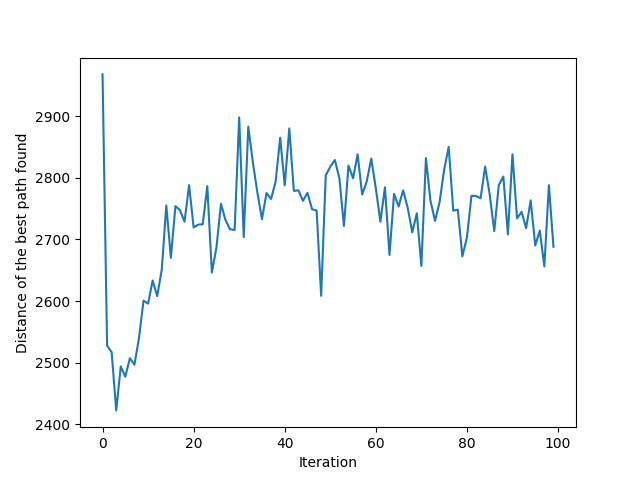
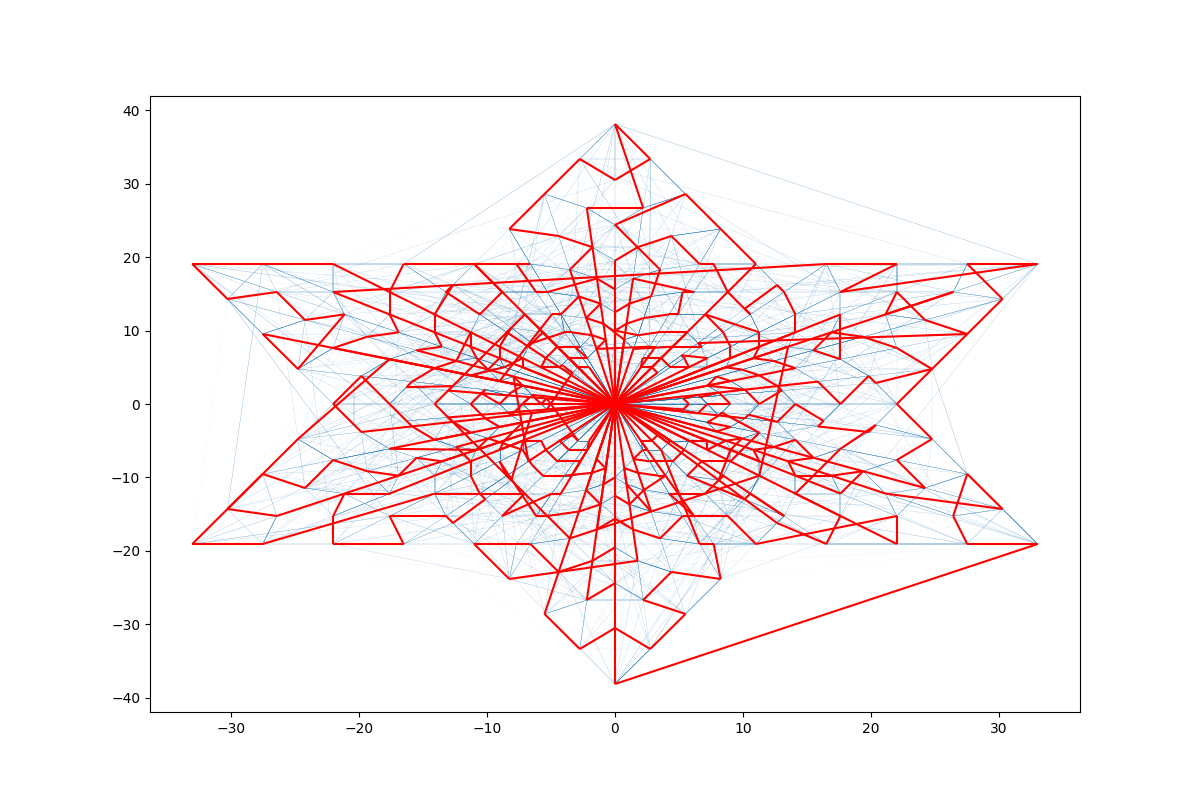


Vstupni soubor: **data_72.xml**
Nejlepší nalezená vzdálenost:  **299.4488976670333**

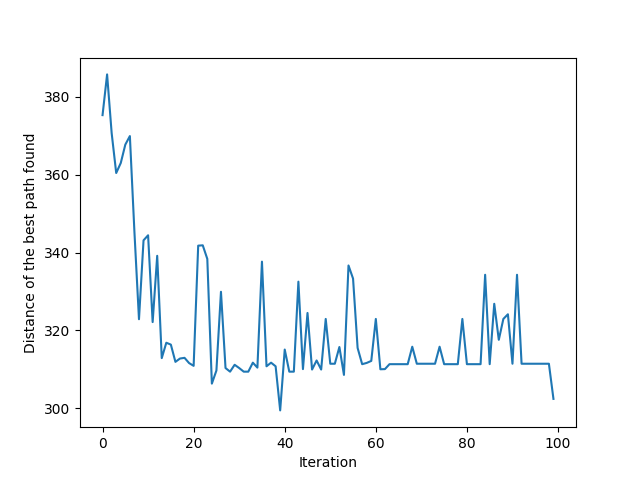
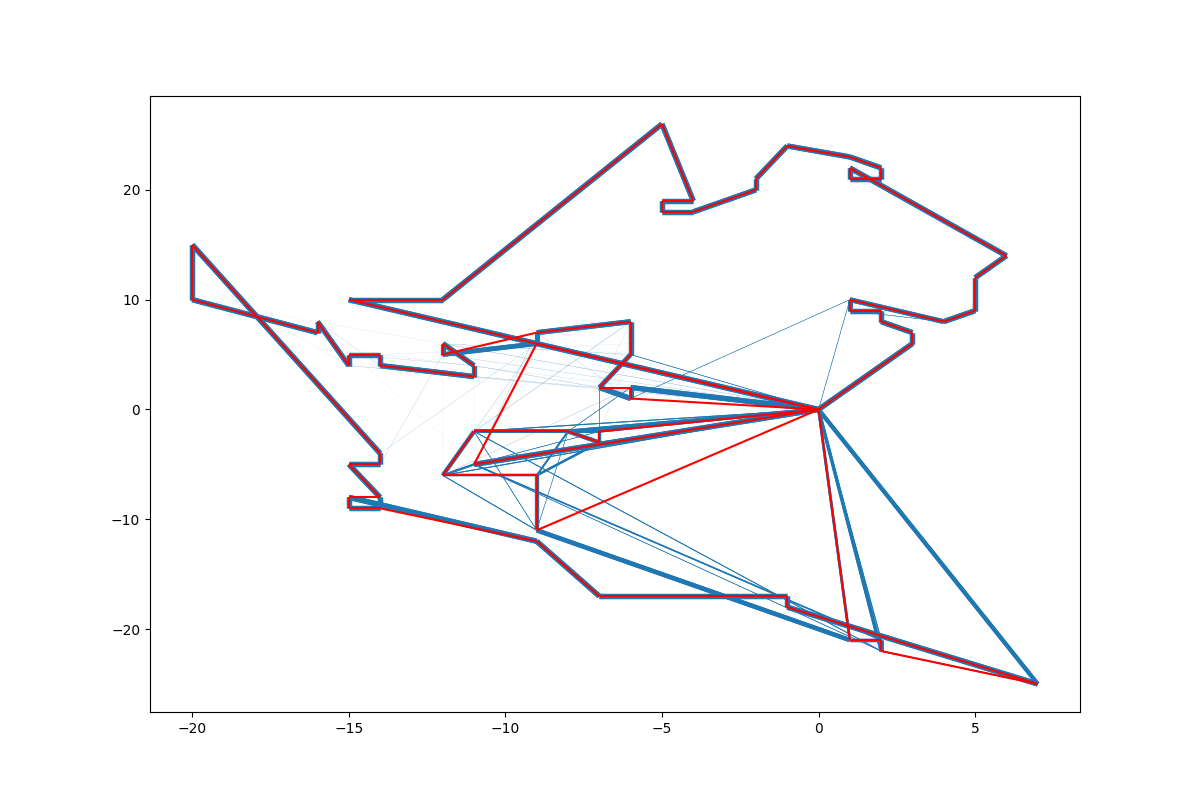

Vstupni soubor: data_32.xml
Nejlepší nalezená vzdálenost:  835.6818436647109

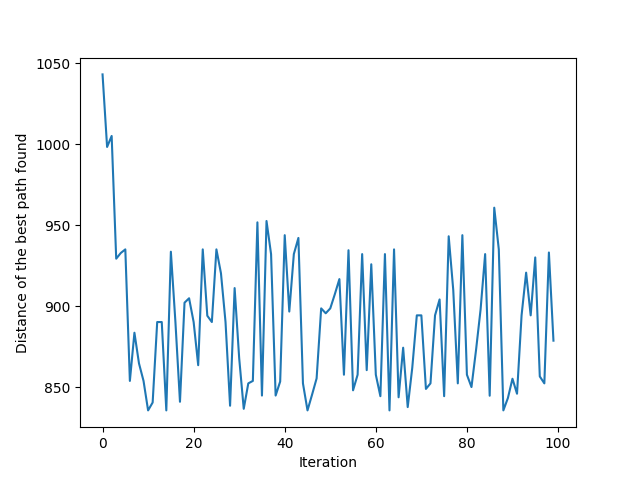
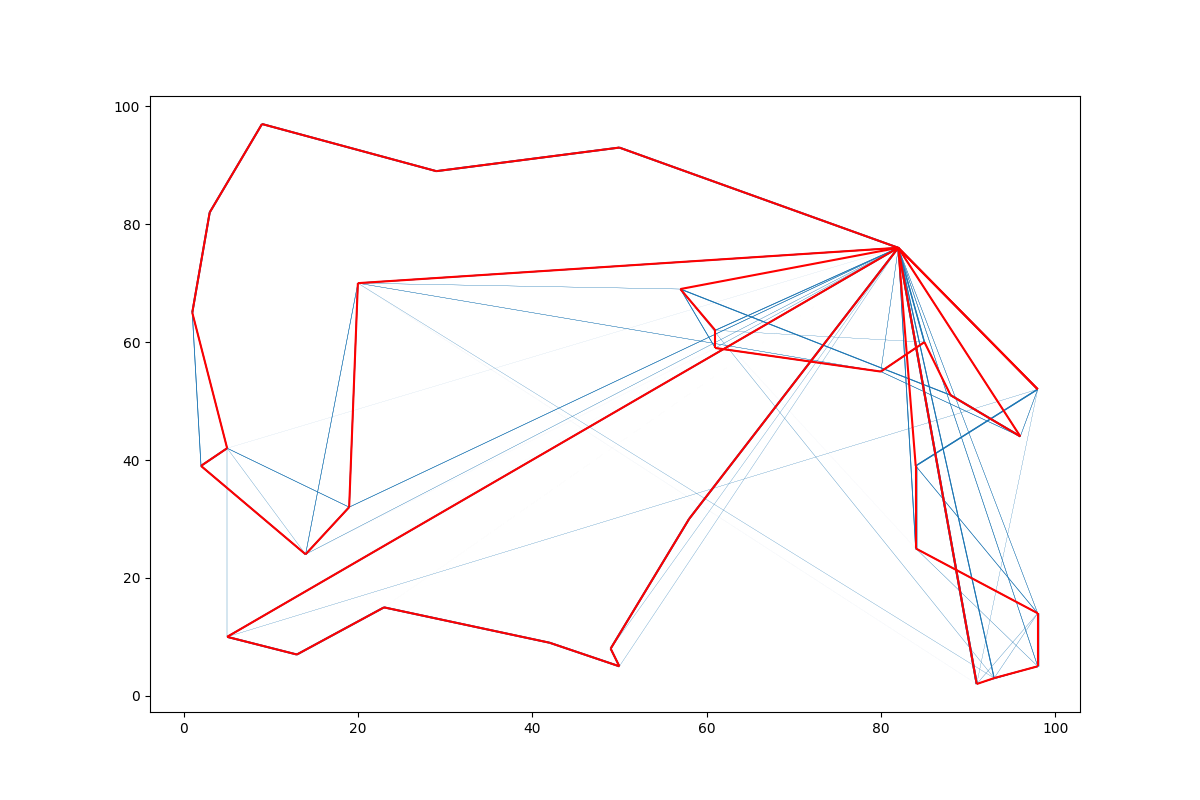



### Nastavení hyperparametrů

* **Počet mravenců (75) a Iterace (100):** Zvýšil jsem počet mravenců, aby feromony byly více využívány.

* **$\alpha = 1.0$ (Feromony) a $\beta = š.0$ (Vzdálenost):** Fakt, že $\beta > \alpha$, je klíčový.  

* **$\rho = 0.8$ (Vypařování):**  0.8 => vysoká míra vypařování. Sice kvůli tomu fitness graf nekonverguje tak dobře, ale špatné výsledky se nepropisují do výsledků ostatních.

